In [ ]:
import pandas as pd

housing_data = pd.read_csv('housing.csv')

print('--- DataFrame Info ---')
housing_data.info()

print('\n--- Descriptive Statistics ---')
housing_data.describe()

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

--- Descriptive Statistics ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


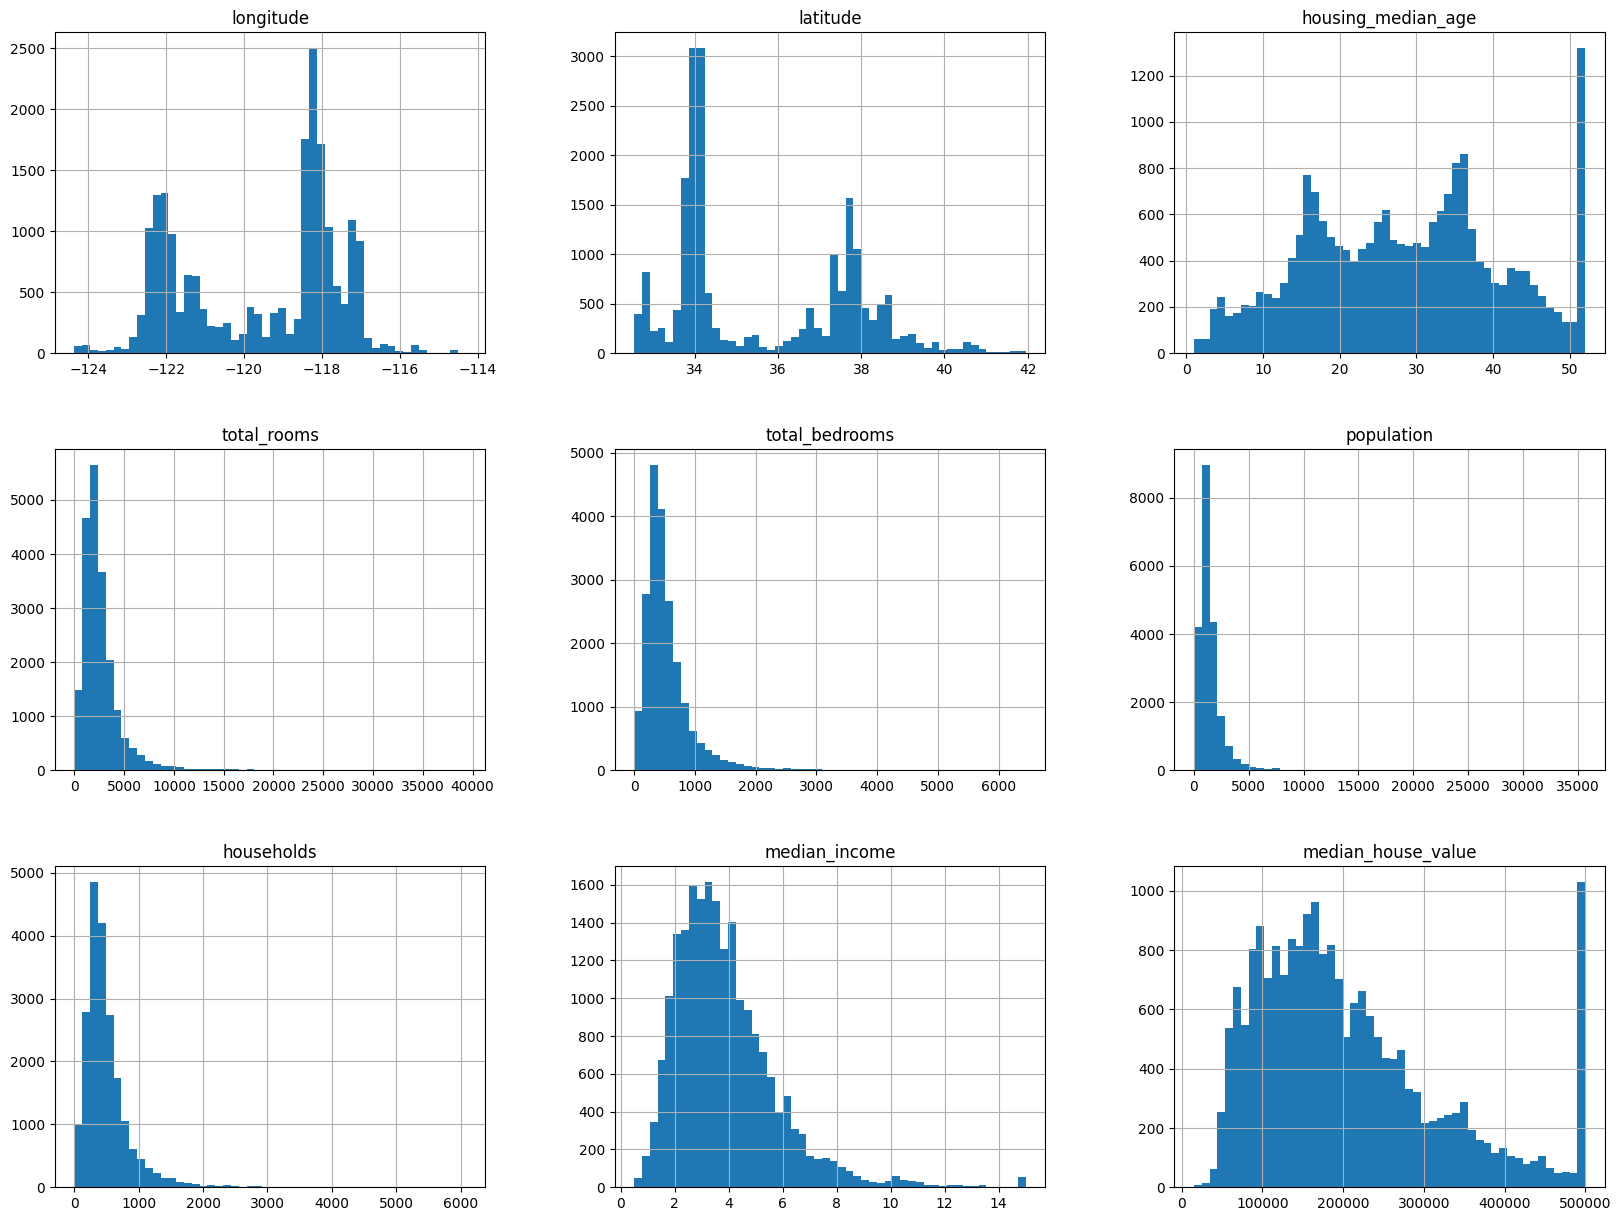

In [ ]:
import matplotlib.pyplot as plt

housing_data.hist(figsize=(20, 15), bins=50)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
print("train_test_split imported successfully.")

train_test_split imported successfully.


In [ ]:
train_set, test_set = train_test_split(housing_data, test_size=0.2, random_state=42)
print(f"Random training set shape: {train_set.shape}")
print(f"Random test set shape: {test_set.shape}")

Random training set shape: (16512, 10)
Random test set shape: (4128, 10)


In [ ]:
import numpy as np

housing_data['income_cat'] = pd.cut(
    housing_data['median_income'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)
print(housing_data['income_cat'].value_counts())

income_cat
3    7236
2    6581
4    3639
5    2362
1     822
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(housing_data, housing_data['income_cat']):
    strat_train_set = housing_data.loc[train_index]
    strat_test_set = housing_data.loc[test_index]

print(f"Stratified training set shape: {strat_train_set.shape}")
print(f"Stratified test set shape: {strat_test_set.shape}")

Stratified training set shape: (16512, 11)
Stratified test set shape: (4128, 11)


In [ ]:
housing_data.drop('income_cat', axis=1, inplace=True)
strat_train_set.drop('income_cat', axis=1, inplace=True)
strat_test_set.drop('income_cat', axis=1, inplace=True)

print("income_cat column dropped from housing_data, strat_train_set, and strat_test_set.")

income_cat column dropped from housing_data, strat_train_set, and strat_test_set.


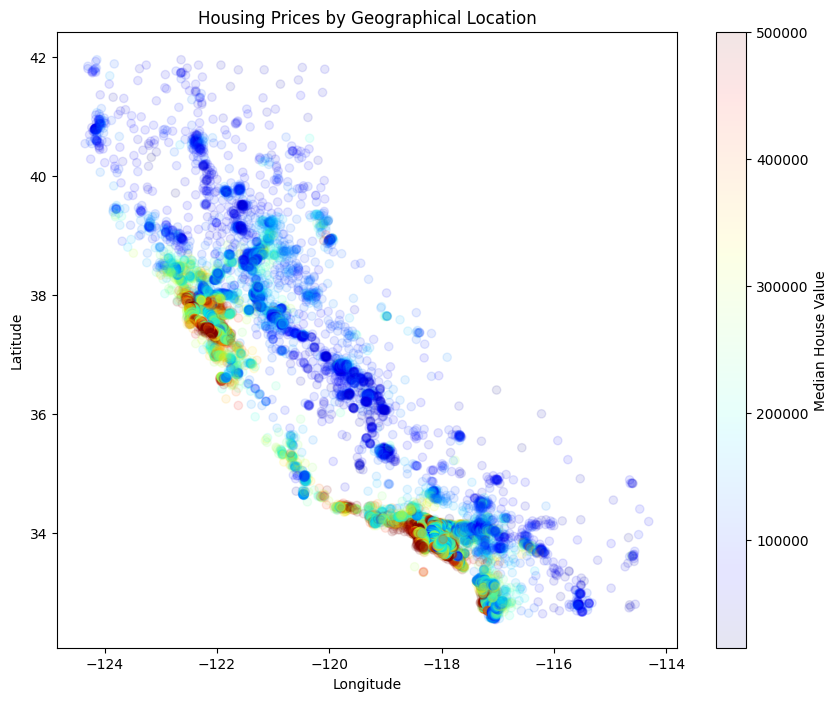

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(housing_data['longitude'], housing_data['latitude'], alpha=0.1, c=housing_data['median_house_value'], cmap='jet')
plt.colorbar(label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Housing Prices by Geographical Location')
plt.show()

In [ ]:
corr_matrix = housing_data.corr(numeric_only=True)
print(corr_matrix['median_house_value'].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


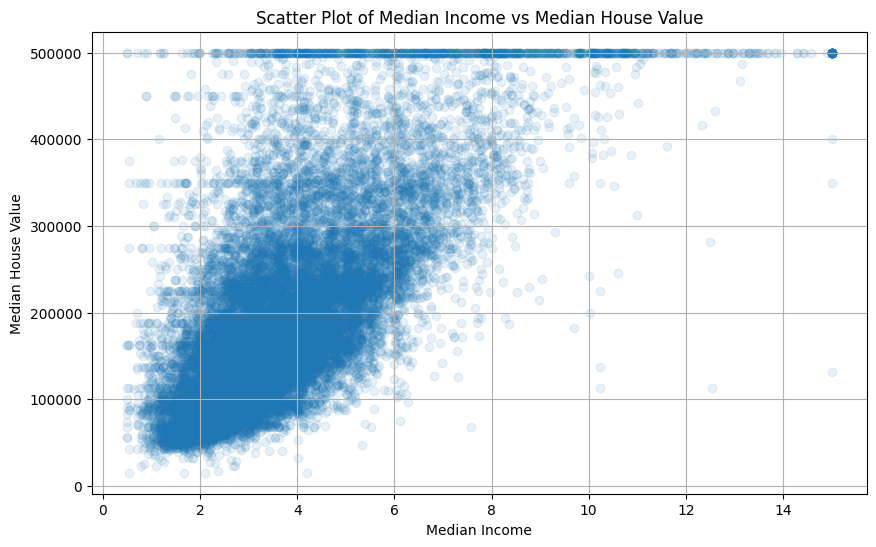

In [ ]:
import matplotlib.pyplot as plt

# Identify the most correlated feature (excluding median_house_value itself)
correlations = corr_matrix['median_house_value'].drop('median_house_value')
most_correlated_feature = correlations.abs().idxmax()

plt.figure(figsize=(10, 6))
plt.scatter(housing_data[most_correlated_feature], housing_data['median_house_value'], alpha=0.1)
plt.xlabel(most_correlated_feature.replace('_', ' ').title())
plt.ylabel('Median House Value')
plt.title(f'Scatter Plot of {most_correlated_feature.replace("_", " ").title()} vs Median House Value')
plt.grid(True)
plt.show()


In [14]:
housing_data['rooms_per_household'] = housing_data['total_rooms'] / housing_data['households']
housing_data['population_per_household'] = housing_data['population'] / housing_data['households']
housing_data['bedrooms_per_room'] = housing_data['total_bedrooms'] / housing_data['total_rooms']

print("--- Housing Data with New Features (First 5 Rows) ---")
print(housing_data.head())

--- Housing Data with New Features (First 5 Rows) ---
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  \
0       322.0       126.0         8.3252            452600.0        NEAR BAY   
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY   
2       496.0       177.0         7.2574            352100.0        NEAR BAY   
3       558.0       219.0         5.6431            341300.0        NEAR BAY   
4       565.0       259.0         3.8462            342200.0        NEAR BAY   

   rooms_per_h

In [15]:
corr_matrix_with_new_features = housing_data.corr(numeric_only=True)
print('--- Correlation Matrix with New Features ---')
print(corr_matrix_with_new_features['median_house_value'].sort_values(ascending=False))

--- Correlation Matrix with New Features ---
median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64


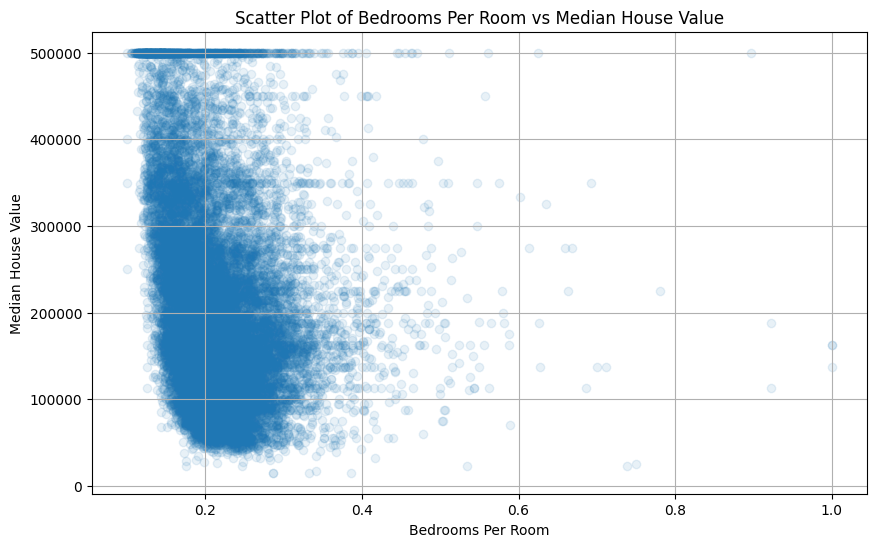

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(housing_data['bedrooms_per_room'], housing_data['median_house_value'], alpha=0.1)
plt.xlabel('Bedrooms Per Room')
plt.ylabel('Median House Value')
plt.title('Scatter Plot of Bedrooms Per Room vs Median House Value')
plt.grid(True)
plt.show()

In [17]:
print("--- Missing values before cleaning ---")
print(housing_data.isnull().sum())

--- Missing values before cleaning ---
longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms              207
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity               0
rooms_per_household           0
population_per_household      0
bedrooms_per_room           207
dtype: int64


In [18]:
median_total_bedrooms = housing_data['total_bedrooms'].median()
housing_data['total_bedrooms'].fillna(median_total_bedrooms, inplace=True)

# Recalculate 'bedrooms_per_room' as it depends on 'total_bedrooms' and had missing values
housing_data['bedrooms_per_room'] = housing_data['total_bedrooms'] / housing_data['total_rooms']

print("--- Missing values after cleaning 'total_bedrooms' and recalculating 'bedrooms_per_room' ---")
print(housing_data.isnull().sum())

--- Missing values after cleaning 'total_bedrooms' and recalculating 'bedrooms_per_room' ---
longitude                   0
latitude                    0
housing_median_age          0
total_rooms                 0
total_bedrooms              0
population                  0
households                  0
median_income               0
median_house_value          0
ocean_proximity             0
rooms_per_household         0
population_per_household    0
bedrooms_per_room           0
dtype: int64


/tmp/ipython-input-2297442150.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing_data['total_bedrooms'].fillna(median_total_bedrooms, inplace=True)


In [19]:
median_total_bedrooms = housing_data['total_bedrooms'].median()
housing_data['total_bedrooms'] = housing_data['total_bedrooms'].fillna(median_total_bedrooms)

# Recalculate 'bedrooms_per_room' as it depends on 'total_bedrooms' and had missing values
housing_data['bedrooms_per_room'] = housing_data['total_bedrooms'] / housing_data['total_rooms']

print("--- Missing values after cleaning 'total_bedrooms' and recalculating 'bedrooms_per_room' ---")
print(housing_data.isnull().sum())

--- Missing values after cleaning 'total_bedrooms' and recalculating 'bedrooms_per_room' ---
longitude                   0
latitude                    0
housing_median_age          0
total_rooms                 0
total_bedrooms              0
population                  0
households                  0
median_income               0
median_house_value          0
ocean_proximity             0
rooms_per_household         0
population_per_household    0
bedrooms_per_room           0
dtype: int64


In [20]:
print("--- Unique values and their counts for 'ocean_proximity' ---")
print(housing_data['ocean_proximity'].value_counts())

--- Unique values and their counts for 'ocean_proximity' ---
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [21]:
housing_data_encoded = pd.get_dummies(housing_data, columns=['ocean_proximity'], prefix='ocean_prox')

print("--- Housing Data after One-Hot Encoding (First 5 Rows) ---")
print(housing_data_encoded.head())

print("\n--- DataFrame Info after One-Hot Encoding ---")
housing_data_encoded.info()

--- Housing Data after One-Hot Encoding (First 5 Rows) ---
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  \
0       322.0       126.0         8.3252            452600.0   
1      2401.0      1138.0         8.3014            358500.0   
2       496.0       177.0         7.2574            352100.0   
3       558.0       219.0         5.6431            341300.0   
4       565.0       259.0         3.8462            342200.0   

   rooms_per_household  population_per_household  bedrooms_per_room  \
0             6.984127            

In [22]:
housing_features = strat_train_set.drop('median_house_value', axis=1)
housing_labels = strat_train_set['median_house_value'].copy()

numerical_features = housing_features.select_dtypes(include=['number']).columns.tolist()
categorical_features = housing_features.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")
print(f"Shape of housing_features: {housing_features.shape}")
print(f"Shape of housing_labels: {housing_labels.shape}")

Numerical features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical features: ['ocean_proximity']
Shape of housing_features: (16512, 9)
Shape of housing_labels: (16512,)


In [23]:
from sklearn.base import BaseEstimator, TransformerMixin

# column index
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self  # nothing else to do
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household,
                         bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

print("Custom transformer CombinedAttributesAdder defined.")

Custom transformer CombinedAttributesAdder defined.


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Pipeline for numerical features
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler()),
])

# Full preprocessing pipeline using ColumnTransformer
# This will apply num_pipeline to numerical_features and OneHotEncoder to categorical_features
# The remainder='passthrough' ensures that any columns not specified are kept as they are
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])

# Apply the full pipeline to the training data
housing_prepared = full_pipeline.fit_transform(housing_features)

print("Full preprocessing pipeline created and applied to training data.")
print(f"Shape of processed training data: {housing_prepared.shape}")

Full preprocessing pipeline created and applied to training data.
Shape of processed training data: (16512, 16)
